In [23]:
# dataset --> https://www.kaggle.com/mlg-ulb/creditcardfraud 

In [116]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix,precision_recall_curve

In [62]:
df=pd.read_csv('creditcard.csv')

In [26]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [27]:
df.shape

(284807, 31)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [29]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### Exploratory Data Analysis

In [30]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [31]:
#checking for duplicated
df.duplicated().sum()

1081

In [32]:
#dropping duplicate columns
df.drop_duplicates(inplace=True)

In [33]:
df['Class_labels']=df['Class'].map({
    0:'Normal',
    1:'Fraud'
})

In [34]:
X=df.drop(columns=['Class','Class_labels'],axis=1)
y=df['Class']

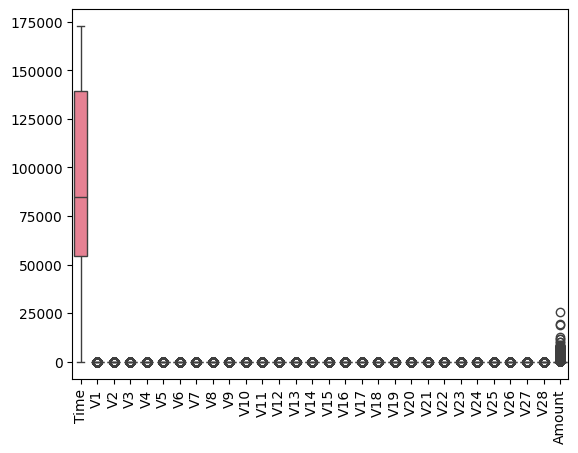

In [35]:
sns.boxplot(X)
plt.xticks(rotation=90)
plt.show()

In [106]:
#IQR

for col in X:
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)

    IQR=Q3 -Q1

    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR

    outlier=df[(df[col] <lower ) |(df[col] >upper)]

    print('\n',col)
    print('lower: ',lower)
    print('upper: ',upper)
    print('outliers: ',len(outlier))


 Time
lower:  -73477.0
upper:  266999.0
outliers:  0

 V1
lower:  -4.274396001792603
upper:  4.669664311280146
outliers:  7062

 V2
lower:  -2.7019605905224315
upper:  2.90713454829761
outliers:  13526

 V3
lower:  -3.7667054090861836
upper:  3.9035361133965982
outliers:  3363

 V4
lower:  -3.236612225031064
upper:  3.1313133981683787
outliers:  11148

 V5
lower:  -2.646882336821933
upper:  2.5672117056694685
outliers:  12295

 V6
lower:  -2.51858636568538
upper:  2.148855653580996
outliers:  22965

 V7
lower:  -2.240843806907704
upper:  2.2572040007487804
outliers:  8948

 V8
lower:  -1.0125931529838397
upper:  1.1313092708678223
outliers:  24134

 V9
lower:  -2.503452471089882
upper:  2.457493931105559
outliers:  8283

 V10
lower:  -2.0194494839425694
upper:  1.9379472025887527
outliers:  9496

 V11
lower:  -3.015625599764853
upper:  2.9927248115734812
outliers:  780

 V12
lower:  -1.941285763020238
upper:  2.1539523105259604
outliers:  15348

 V13
lower:  -2.6151056869463822
upper:

In [41]:
X.corr(numeric_only=True)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Time,1.000000,0.117927,-0.010556,-0.422054,-0.105845,0.173223,-0.063279,0.085335,-0.038203,-0.007861,...,-0.051022,0.045913,0.143727,0.051474,-0.015954,-0.233262,-0.041818,-0.005171,-0.009305,-0.010559
V1,0.117927,1.000000,0.006875,-0.008112,0.002257,-0.007036,0.000413,-0.009173,-0.001168,0.001828,...,-0.001393,0.002818,-0.001436,-0.001330,-0.000723,-0.000222,-0.000684,-0.015706,-0.004861,-0.230105
V2,-0.010556,0.006875,1.000000,0.005278,-0.001495,0.005210,-0.000594,0.007425,0.002899,-0.000274,...,-0.001287,-0.004897,0.001237,-0.003855,0.000701,-0.001569,0.000253,0.007555,0.001611,-0.533428
V3,-0.422054,-0.008112,0.005278,1.000000,0.002829,-0.006879,-0.001511,-0.011721,-0.001815,-0.003579,...,-0.002269,0.003500,-0.000275,0.000449,-0.000072,0.000425,-0.000094,-0.007051,-0.000134,-0.212410
V4,-0.105845,0.002257,-0.001495,0.002829,1.000000,0.001744,-0.000880,0.004657,0.000890,0.002154,...,0.000318,-0.001034,0.000115,0.000732,-0.000120,0.000162,0.000777,0.001322,0.000231,0.099514
V5,0.173223,-0.007036,0.005210,-0.006879,0.001744,1.000000,-0.000938,-0.008709,0.001430,-0.001213,...,-0.001185,0.001622,-0.000559,0.001183,0.000198,0.000069,0.000390,-0.005798,-0.000820,-0.387685
V6,-0.063279,0.000413,-0.000594,-0.001511,-0.000880,-0.000938,1.000000,0.000436,0.003036,-0.000734,...,-0.000181,-0.002134,0.001104,-0.000755,0.001202,0.000697,-0.000028,0.000289,0.000925,0.216389
V7,0.085335,-0.009173,0.007425,-0.011721,0.004657,-0.008709,0.000436,1.000000,-0.006419,-0.004921,...,-0.001192,0.009010,-0.002280,0.003303,-0.000384,-0.000072,0.000624,-0.004537,0.001657,0.400408
V8,-0.038203,-0.001168,0.002899,-0.001815,0.000890,0.001430,0.003036,-0.006419,1.000000,0.001038,...,0.000271,0.018892,-0.006156,0.004994,0.000113,0.000011,-0.001407,0.000613,-0.000099,-0.104662
V9,-0.007861,0.001828,-0.000274,-0.003579,0.002154,-0.001213,-0.000734,-0.004921,0.001038,1.000000,...,-0.001838,0.000679,0.000785,0.000677,-0.000103,-0.000275,0.001253,0.008221,0.005591,-0.044123


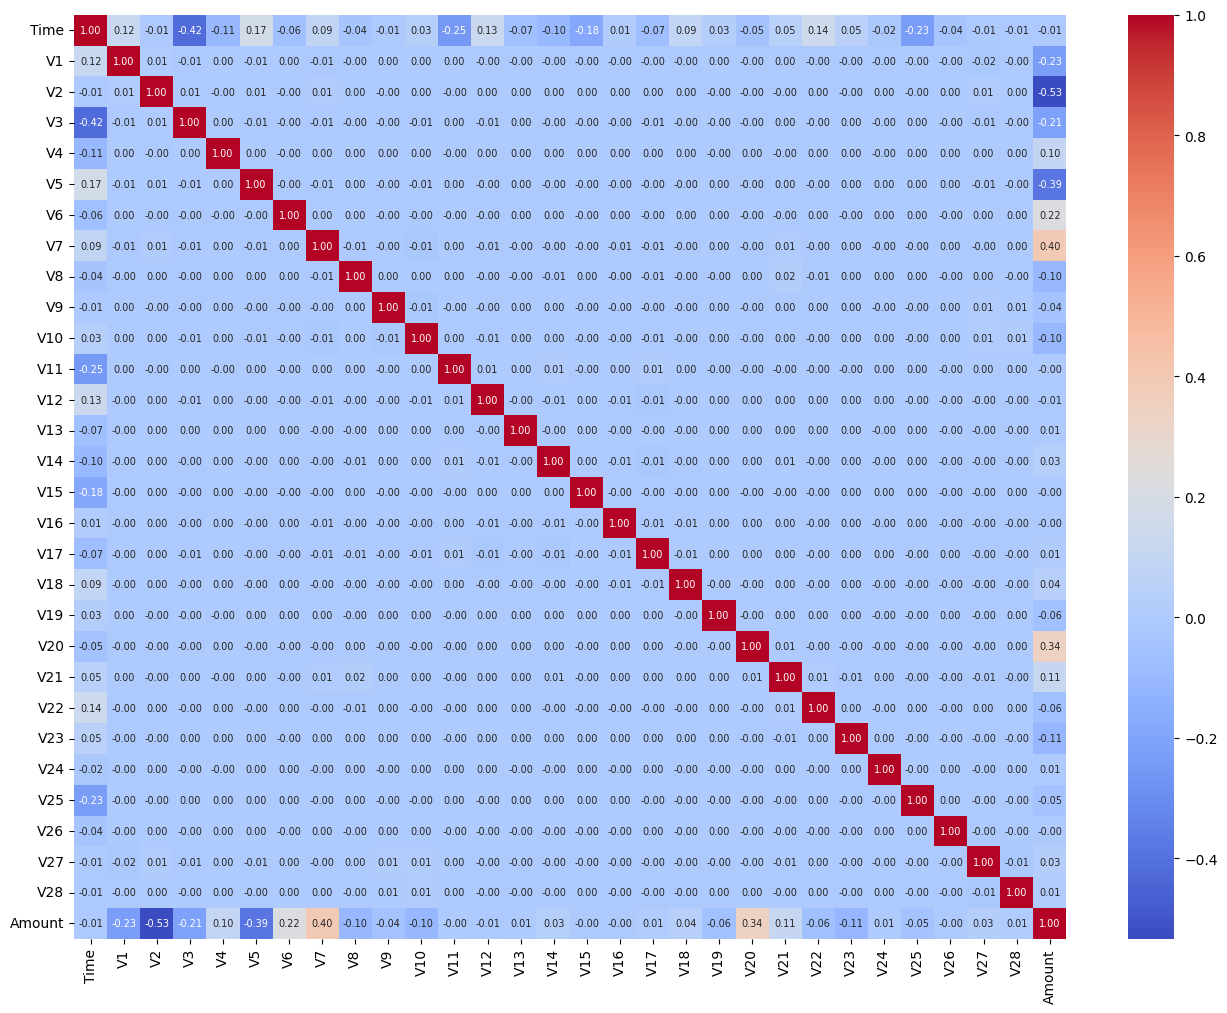

In [ ]:
plt.figure(figsize=(16,12))
sns.heatmap( X.corr(),
            annot=True,
            cmap='coolwarm',
            annot_kws={'size':7},
            fmt='.2f')
plt.show()

In [38]:
y.value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [83]:
y.value_counts(normalize=True)*100

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

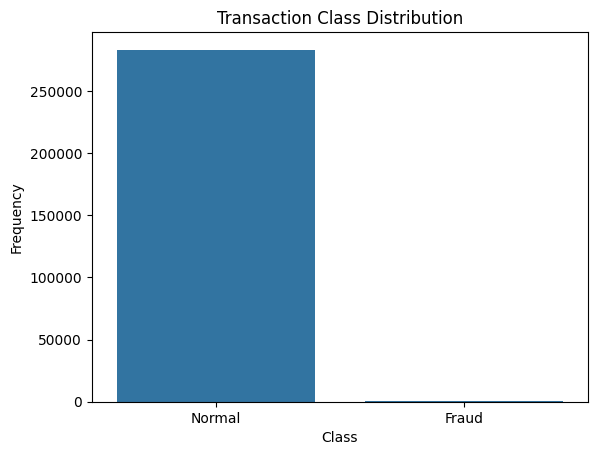

In [37]:
target=df['Class_labels'].value_counts()
sns.barplot(target)
plt.title('Transaction Class Distribution')
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.show()

<Axes: xlabel='Amount', ylabel='Count'>

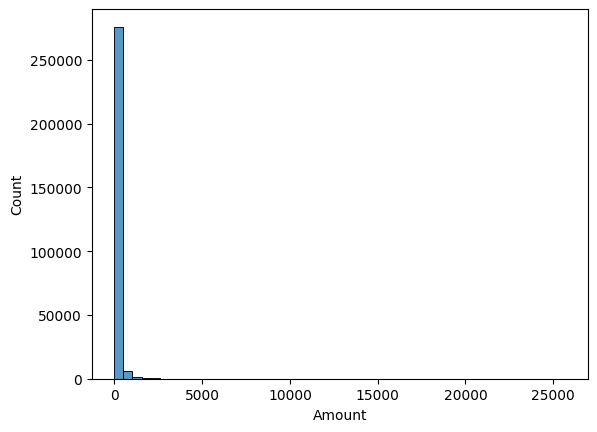

In [119]:
# Amount Distribution
sns.histplot(df['Amount'],bins=50)

<Axes: xlabel='Class', ylabel='count'>

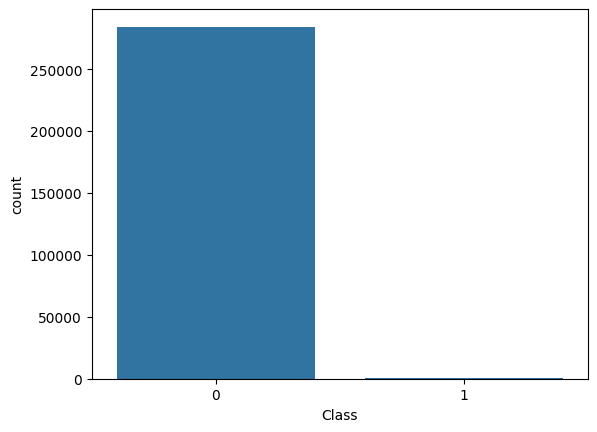

In [ ]:
#Target Distribution
sns.countplot(data=df, x='Class')

In [120]:
df.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


In [87]:
df.groupby('Class')['Time'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,94838.202258,47484.015786,0.0,54230.0,84711.0,139333.0,172792.0
1,492.0,80746.806911,47835.365138,406.0,41241.5,75568.5,128483.0,170348.0


In [124]:
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
X_scaled=scaler.fit_transform(X)

In [122]:
model=IsolationForest(
                    random_state=42,
                    n_estimators=100,
                    contamination='auto',
                    n_jobs=-1
                    )

In [125]:
model.fit(X_scaled)

,n_estimators,100
,max_samples,'auto'
,contamination,'auto'
,max_features,1.0
,bootstrap,False
,n_jobs,-1
,random_state,42
,verbose,0
,warm_start,False


In [94]:
pred=model.predict(X_scaled)

In [96]:
import numpy as np

y_pred = np.where(pred == -1, 1, 0)

In [ ]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [101]:
np.unique(y_pred, return_counts=True)

(array([0, 1]), array([272972,  10754], dtype=int64))

In [102]:
pd.Series(y_pred).value_counts()

0    272972
1     10754
Name: count, dtype: int64

In [103]:
print("Actual:")
print(pd.Series(y).value_counts())

print("\nPredicted:")
print(pd.Series(y_pred).value_counts())

Actual:
Class
0    283253
1       473
Name: count, dtype: int64

Predicted:
0    272972
1     10754
Name: count, dtype: int64


In [ ]:
cm = confusion_matrix(y, y_pred)
print(cm)

[[272884  10369]
 [    88    385]]


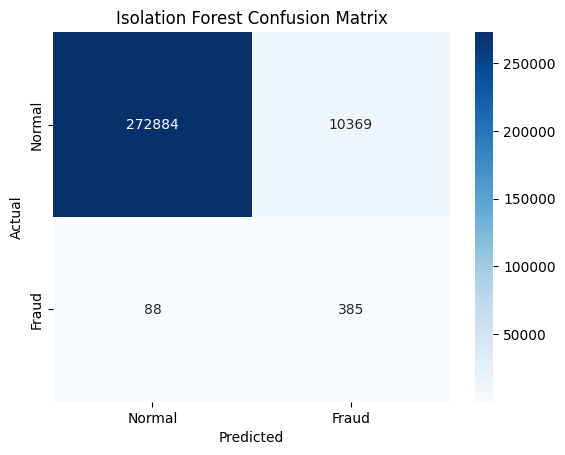

In [ ]:
cm = confusion_matrix(y, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Normal', 'Fraud'],
    yticklabels=['Normal', 'Fraud']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Isolation Forest Confusion Matrix')
plt.show()

In [109]:
print(classification_report(y,y_pred,target_names=['Normal', 'Fraud']))

              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98    283253
       Fraud       0.04      0.81      0.07       473

    accuracy                           0.96    283726
   macro avg       0.52      0.89      0.52    283726
weighted avg       1.00      0.96      0.98    283726



In [110]:
accuracy_score(y, y_pred)

0.9631440192298203

In [113]:
scores = -model.decision_function(X_scaled)

In [114]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y, scores)

print("PR-AUC:", pr_auc)

PR-AUC: 0.09034617009444403
